In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

TRADING_DAYS = 252
RISK_FREE_RATE = 0.02

# Load data
files = glob.glob("../data/raw/stock_prices_*.csv")
latest_file = max(files, key=os.path.getctime)

prices = pd.read_csv(latest_file, index_col=0, parse_dates=True)

returns = prices.pct_change().dropna()


In [2]:
# Risk-return metrics
stats = pd.DataFrame({
    "annual_return": returns.mean() * TRADING_DAYS,
    "annual_volatility": returns.std() * np.sqrt(TRADING_DAYS),
})

stats["sharpe_ratio"] = (
    (stats["annual_return"] - RISK_FREE_RATE) /
    stats["annual_volatility"]
)

stats = stats.sort_values("sharpe_ratio", ascending=False)
stats


,annual_return,annual_volatility,sharpe_ratio
NVDA,0.987150,0.502226,1.925726
META,0.632396,0.381547,1.605032
GOOGL,0.470087,0.302746,1.486681
SPY,0.220530,0.153507,1.306330
AMZN,0.382957,0.319368,1.136487
AAPL,0.298152,0.256012,1.086481
MSFT,0.270496,0.232048,1.079503
TSLA,0.656810,0.600591,1.060305


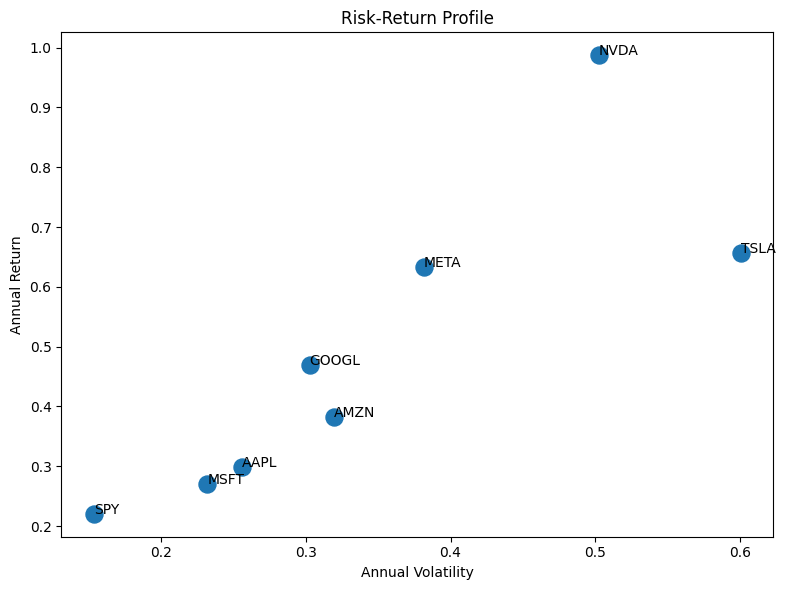

In [3]:
# Risk-return scatter
plt.figure(figsize=(8, 6))
plt.scatter(
    stats["annual_volatility"],
    stats["annual_return"],
    s=150
)

for ticker in stats.index:
    plt.annotate(
        ticker,
        (
            stats.loc[ticker, "annual_volatility"],
            stats.loc[ticker, "annual_return"]
        )
    )

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Risk-Return Profile")
plt.tight_layout()
plt.show()


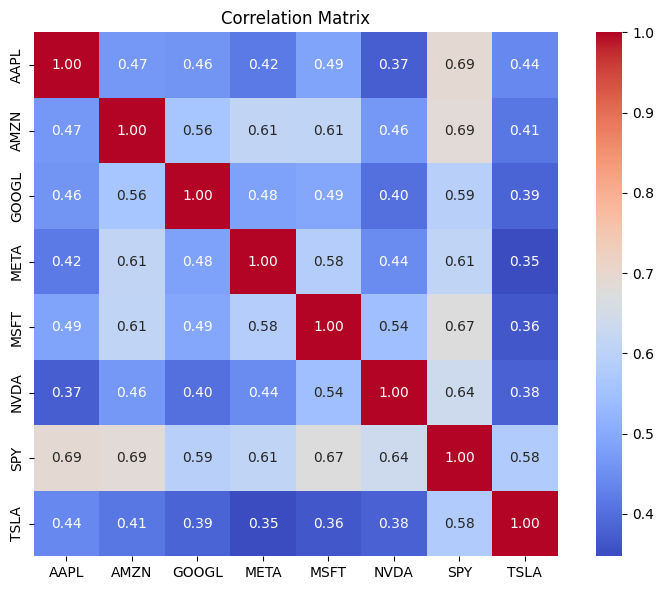

In [4]:
# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    returns.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


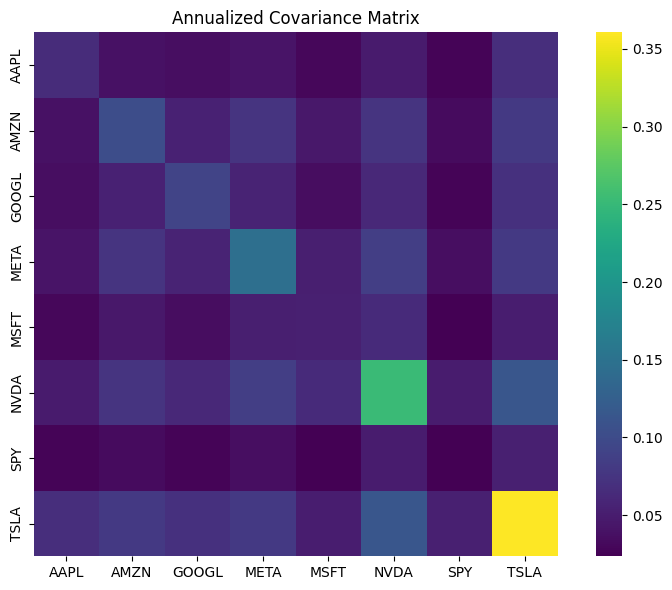

In [5]:
# Covariance matrix (annualized)
cov_matrix = returns.cov() * TRADING_DAYS

plt.figure(figsize=(8, 6))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="viridis",
    square=True
)
plt.title("Annualized Covariance Matrix")
plt.tight_layout()
plt.show()
